<a href="https://colab.research.google.com/github/sanjibmandal0203/masters/blob/multimodel/CNN%20classification%20test%20on%20new%20ECG%20PCG%20(128%2B128%3D256).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# Load feature and target data
features = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/dl/dataset/ECG PCG feature(128+128=256).csv", header=None, skiprows=[0])  # Adjust header based on your CSV format
targets = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/dl/dataset/Reference_aug.csv', header=None)

In [ ]:
print(features.shape)
print(targets.shape)

# Extract target column
y = targets.iloc[:, -1]  # Selecting the last column
X = features  # All feature columns

# Using .apply() method
y = y.apply(lambda x: max(x, 0))

(1975, 256)
(1975, 2)


In [ ]:
# Split data into training and testing sets
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize features
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

# Reshape data for Conv1D input
Xtrain_reshaped = Xtrain_scaled.reshape((Xtrain_scaled.shape[0], Xtrain_scaled.shape[1], 1))
Xtest_reshaped = Xtest_scaled.reshape((Xtest_scaled.shape[0], Xtest_scaled.shape[1], 1))

# **CNN**

In [ ]:
model = Sequential([
    Conv1D(filters=8, kernel_size=3, activation='relu', input_shape=(256, 1)),
    BatchNormalization(),
    Dropout(0.5),
    Conv1D(filters=16, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Conv1D(filters=16, kernel_size=3, activation='relu'),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # 2 output classes for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(Xtrain_reshaped, Ytrain, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5022 - loss: 0.7391 - val_accuracy: 0.4968 - val_loss: 0.6904
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5484 - loss: 0.6866 - val_accuracy: 0.5158 - val_loss: 0.6867
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6139 - loss: 0.6550 - val_accuracy: 0.4937 - val_loss: 0.6934
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6293 - loss: 0.6442 - val_accuracy: 0.5981 - val_loss: 0.6660
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6360 - loss: 0.6253 - val_accuracy: 0.6772 - val_loss: 0.6386
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6467 - loss: 0.6486 - val_accuracy: 0.6646 - val_loss: 0.6414
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6890 - loss: 0.6026 - val_accuracy: 0.6456 - val_loss: 0.6391
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7002 - loss: 0.5816 - val_accuracy: 0.

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(Xtest_reshaped, Ytest)
print(f"Test Accuracy: {accuracy:.2%}")
print(f"Test Loss: {loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7024 - loss: 1.9197
Test Accuracy: 70.63%
Test Loss: 1.8710


In [ ]:
Ypred = model.predict(Xtest_reshaped)
Ypred_classes = (Ypred > 0.5).astype(int)
Ypred_classes_flat = Ypred_classes.flatten()

# Print classification report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(Ytest, Ypred_classes_flat)) # Use Ytest directly

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.78      0.72       190
           1       0.76      0.63      0.69       205

    accuracy                           0.71       395
   macro avg       0.71      0.71      0.71       395
weighted avg       0.71      0.71      0.71       395



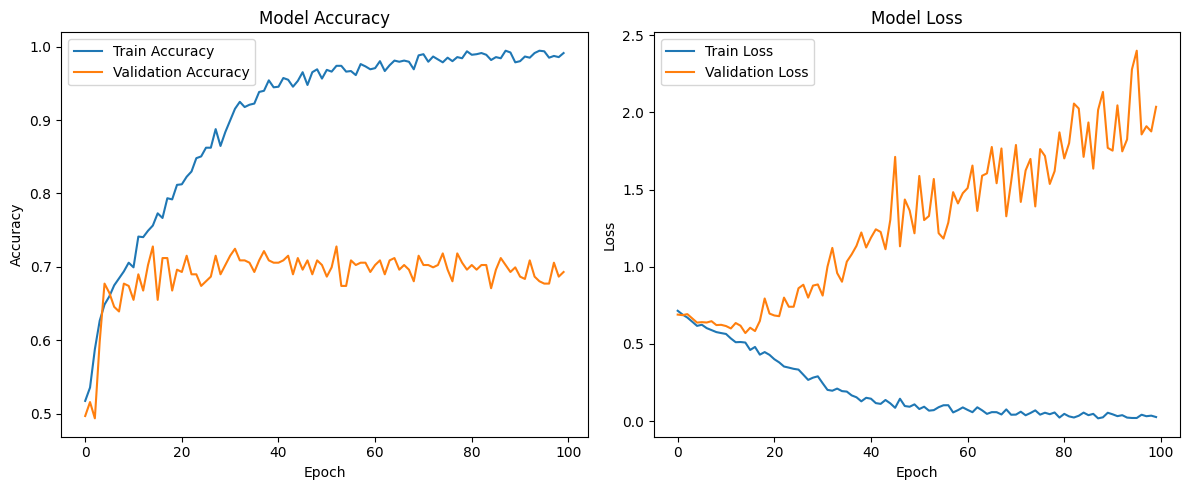

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


ROC AUC: 0.7771


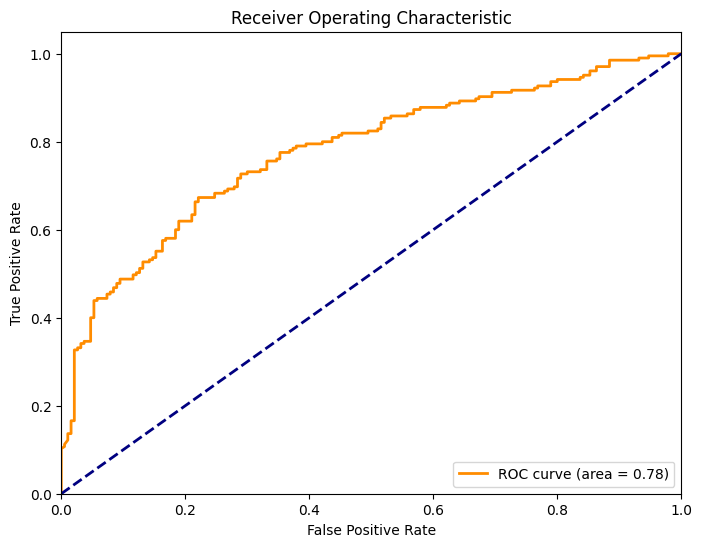

In [ ]:
roc_auc = roc_auc_score(Ytest, Ypred[:, 0])
print(f"\nROC AUC: {roc_auc:.4f}")

# Plot ROC curve
# Use Ytest for true labels and Ypred[:, 0] for predicted probabilities of the positive class
fpr, tpr, thresholds = roc_curve(Ytest, Ypred[:, 0])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

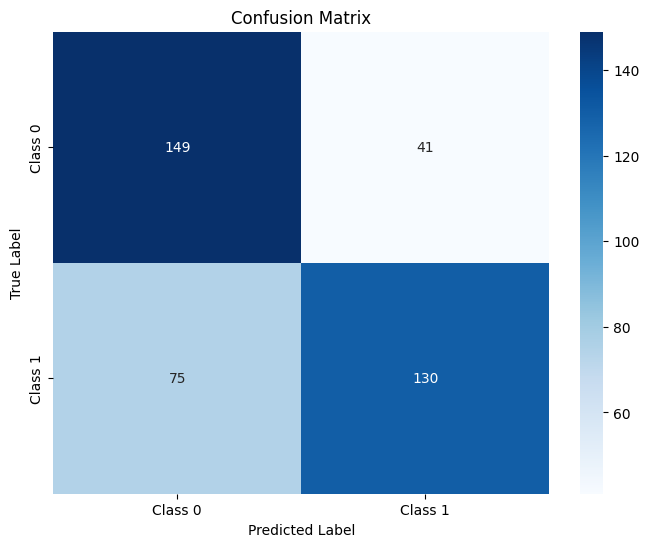

In [ ]:
cm = confusion_matrix(Ytest, Ypred_classes_flat)
plt.figure(figsize=(8, 6))
class_labels = ['Class 0', 'Class 1'] # Or provide your actual class names if available

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()